# 03 - Evaluation Detaillee
Matrice de confusion, metriques, courbe ROC, analyse des erreurs

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
import seaborn as sns

In [2]:
# Configuration
DATA_DIR = Path('../data/chest_xray')
MODEL_PATH = Path('../outputs/checkpoints/best_model.pt')
IMG_SIZE = 224
BATCH_SIZE = 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Charger le modele et les donnees

In [3]:
# Redefinir le modele (meme architecture que notebook 02 - SANS Sigmoid)
class CNNBaseline(nn.Module):
    def __init__(self):
        super(CNNBaseline, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
            # Pas de Sigmoid - on utilise BCEWithLogitsLoss
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Charger le modele
model = CNNBaseline().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()
print("Modele charge!")

Modele charge!


In [4]:
# Charger le test set
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Test set: {len(test_dataset)} images")
print(f"Classes: {test_dataset.classes}")

Test set: 624 images
Classes: ['NORMAL', 'PNEUMONIA']


## 2. Predictions sur le Test Set

In [5]:
# Obtenir toutes les predictions
all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)  # Logits
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()  # Convertir en probabilites
        preds = (probs > 0.5).astype(float)
        
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        all_preds.extend(preds)

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

print(f"Predictions effectuees: {len(all_preds)}")

Predictions effectuees: 624


## 3. Matrice de Confusion

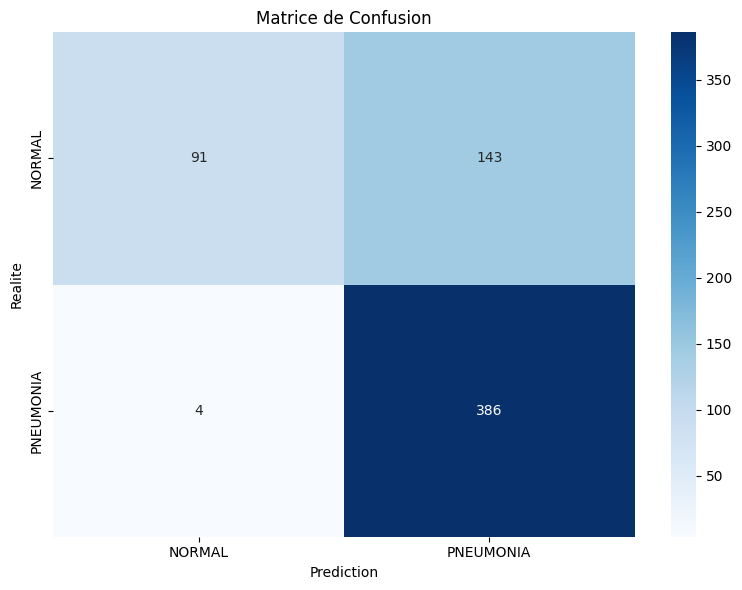


True Negatives (TN): 91 - NORMAL bien classifie
False Positives (FP): 143 - NORMAL classe comme PNEUMONIA
False Negatives (FN): 4 - PNEUMONIA classe comme NORMAL (DANGEREUX!)
True Positives (TP): 386 - PNEUMONIA bien classifie


In [6]:
# Calculer la matrice de confusion
cm = confusion_matrix(all_labels, all_preds)

# Afficher
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            ax=ax)
ax.set_xlabel('Prediction')
ax.set_ylabel('Realite')
ax.set_title('Matrice de Confusion')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix.png', dpi=150)
plt.show()

# Extraire les valeurs
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn} - NORMAL bien classifie")
print(f"False Positives (FP): {fp} - NORMAL classe comme PNEUMONIA")
print(f"False Negatives (FN): {fn} - PNEUMONIA classe comme NORMAL (DANGEREUX!)")
print(f"True Positives (TP): {tp} - PNEUMONIA bien classifie")

## 4. Metriques Detaillees

In [7]:
# Rapport de classification
print("=" * 60)
print("RAPPORT DE CLASSIFICATION")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      NORMAL       0.96      0.39      0.55       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.84      0.69      0.70       624
weighted avg       0.82      0.76      0.73       624



In [8]:
# Calculer les metriques manuellement
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensibilite
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 60)
print("METRIQUES PRINCIPALES")
print("=" * 60)
print(f"Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:   {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:      {recall:.4f} ({recall*100:.2f}%) <- Sensibilite (detecter les malades)")
print(f"Specificity: {specificity:.4f} ({specificity*100:.2f}%) <- (detecter les sains)")
print(f"F1-Score:    {f1:.4f}")

METRIQUES PRINCIPALES
Accuracy:    0.7644 (76.44%)
Precision:   0.7297 (72.97%)
Recall:      0.9897 (98.97%) <- Sensibilite (detecter les malades)
Specificity: 0.3889 (38.89%) <- (detecter les sains)
F1-Score:    0.8400


## 5. Courbe ROC et AUC

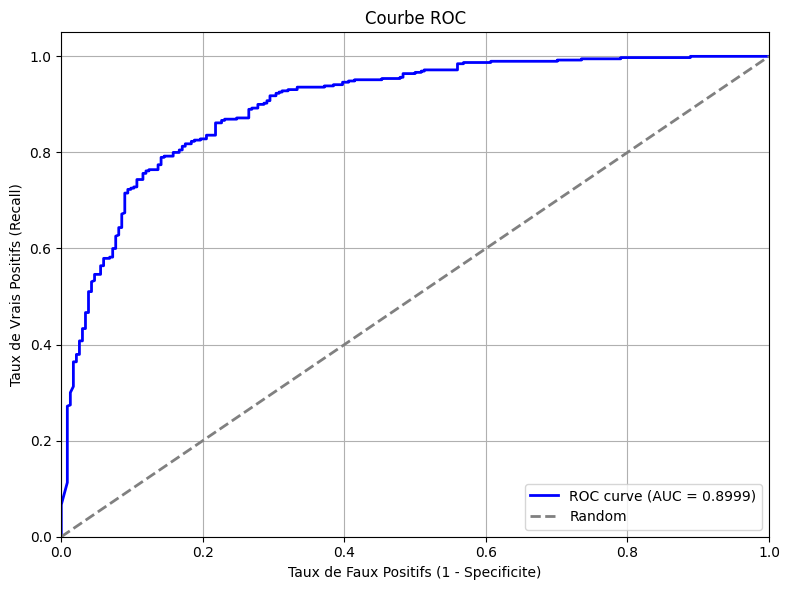

AUC: 0.8999


In [9]:
# Calculer la courbe ROC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Tracer
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de Faux Positifs (1 - Specificite)')
ax.set_ylabel('Taux de Vrais Positifs (Recall)')
ax.set_title('Courbe ROC')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curve.png', dpi=150)
plt.show()

print(f"AUC: {roc_auc:.4f}")

## 6. Courbe Precision-Recall

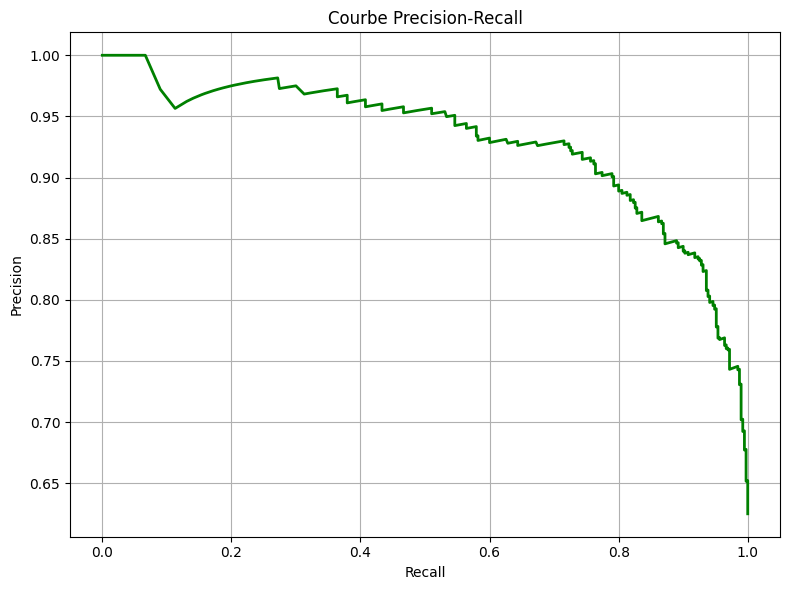

In [10]:
# Calculer la courbe Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_curve, precision_curve, color='green', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Courbe Precision-Recall')
ax.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/precision_recall_curve.png', dpi=150)
plt.show()

## 7. Analyse des Erreurs

In [11]:
# Trouver les indices des erreurs
errors_idx = np.where(all_preds != all_labels)[0]
fn_idx = np.where((all_preds == 0) & (all_labels == 1))[0]  # Faux Negatifs
fp_idx = np.where((all_preds == 1) & (all_labels == 0))[0]  # Faux Positifs

print(f"Total erreurs: {len(errors_idx)}")
print(f"Faux Negatifs (PNEUMONIA -> NORMAL): {len(fn_idx)} <- CRITIQUE")
print(f"Faux Positifs (NORMAL -> PNEUMONIA): {len(fp_idx)}")

Total erreurs: 147
Faux Negatifs (PNEUMONIA -> NORMAL): 4 <- CRITIQUE
Faux Positifs (NORMAL -> PNEUMONIA): 143



FAUX NEGATIFS (PNEUMONIA classee comme NORMAL):


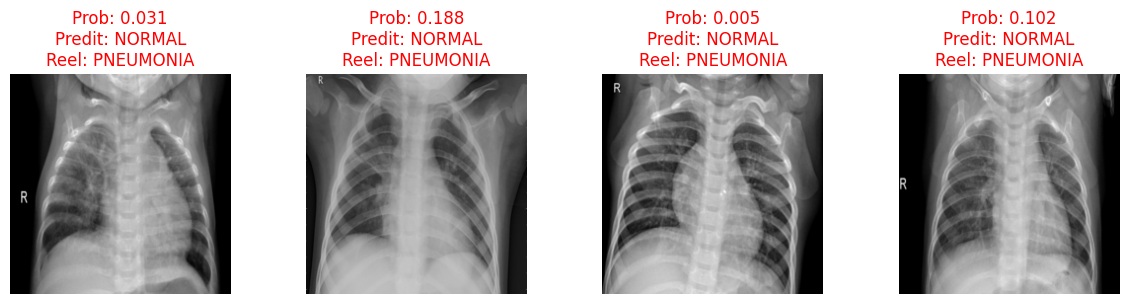

In [12]:
# Visualiser quelques faux negatifs (les plus dangereux)
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

if len(fn_idx) > 0:
    print("\nFAUX NEGATIFS (PNEUMONIA classee comme NORMAL):")
    fig, axes = plt.subplots(1, min(4, len(fn_idx)), figsize=(12, 3))
    if len(fn_idx) == 1:
        axes = [axes]
    
    for i, idx in enumerate(fn_idx[:4]):
        img, label = test_dataset[idx]
        img_display = denormalize(img).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)
        
        axes[i].imshow(img_display)
        axes[i].set_title(f"Prob: {all_probs[idx]:.3f}\nPredit: NORMAL\nReel: PNEUMONIA", color='red')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/false_negatives.png', dpi=150)
    plt.show()


FAUX POSITIFS (NORMAL classee comme PNEUMONIA):


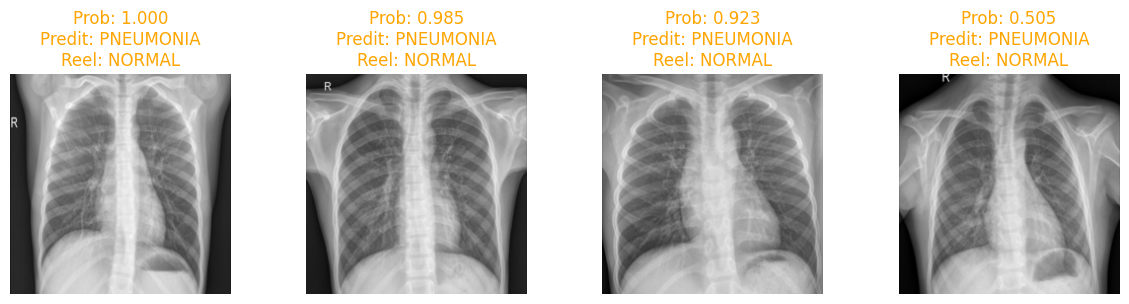

In [13]:
# Visualiser quelques faux positifs
if len(fp_idx) > 0:
    print("\nFAUX POSITIFS (NORMAL classee comme PNEUMONIA):")
    fig, axes = plt.subplots(1, min(4, len(fp_idx)), figsize=(12, 3))
    if len(fp_idx) == 1:
        axes = [axes]
    
    for i, idx in enumerate(fp_idx[:4]):
        img, label = test_dataset[idx]
        img_display = denormalize(img).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)
        
        axes[i].imshow(img_display)
        axes[i].set_title(f"Prob: {all_probs[idx]:.3f}\nPredit: PNEUMONIA\nReel: NORMAL", color='orange')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/false_positives.png', dpi=150)
    plt.show()

## 8. Optimisation du Seuil

In [14]:
# Tester differents seuils
thresholds_test = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Impact du seuil de decision:")
print("=" * 70)
print(f"{'Seuil':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("=" * 70)

for thresh in thresholds_test:
    preds_thresh = (all_probs >= thresh).astype(int)
    cm_thresh = confusion_matrix(all_labels, preds_thresh)
    tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()
    
    acc_t = (tp_t + tn_t) / (tp_t + tn_t + fp_t + fn_t)
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t = 2 * (prec_t * rec_t) / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0
    
    print(f"{thresh:<10} {acc_t:<12.4f} {prec_t:<12.4f} {rec_t:<12.4f} {f1_t:<12.4f}")

Impact du seuil de decision:
Seuil      Accuracy     Precision    Recall       F1          
0.3        0.7436       0.7122       0.9897       0.8283      
0.4        0.7564       0.7228       0.9897       0.8355      
0.5        0.7644       0.7297       0.9897       0.8400      
0.6        0.7676       0.7333       0.9872       0.8415      
0.7        0.7724       0.7431       0.9718       0.8422      


## Resume

### Resultats du modele baseline:
- **Accuracy**: ~76%
- **AUC**: a verifier
- **Recall**: important en medical (eviter les faux negatifs)

### Points d'amelioration:
1. Reduire l'overfitting (augmentation, regularisation)
2. Transfer learning (ResNet, DenseNet)
3. Ajuster le seuil pour optimiser le recall

### Prochain notebook:
- Amelioration du modele (notebook 04)